# RAG Evaluation Case Study: When End-to-End Metrics Hide Component Failures

**O'Reilly Live Course**: *Statistical Testing for LLM Evaluations*
**Subtitle**: *Design Experiments that Detect Real Improvements*
**Instructors**: Rudrendu Paul · Lorenzo Toni
**Section 4 (10 min): Real-World Failure Case 1 of 2: RAG silent degradation (5 min)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---

## What this notebook covers

A production RAG system can rot for weeks while its end-to-end dashboard stays green. This case study reproduces that exact failure with synthetic data, then shows the component-level tests that would have caught it on day one.

Here is the slide version (Section 4 of the live course). The document collection drifts. The end-to-end composite barely moves. But once you look at component-level evaluation, retrieval recall has collapsed by roughly 14 percentage points, from about 0.82 down to 0.68, while answer relevance sits exactly where it was. The generator hides the damage by falling back on parametric knowledge, and the composite weighting dilutes whatever signal is left.

The argument is simple. End-to-end faithfulness, answer relevance, RAGAS scores: these are all aggregates. They blend retriever performance and generator performance into one number. When one component breaks and the other quietly covers for it, the aggregate holds steady even though the system has slipped into a fragile state.

This notebook walks through:

1. **Simulating a RAG system** with realistic component-level metrics across two time periods
2. **The trap of end-to-end metrics**, and how a team watching only the aggregate would miss a real problem
3. **Component isolation** with the correct statistical test on each metric
4. **Designing a controlled retriever swap experiment** with adequate power

Companion book: *Statistical Evaluation Methods for AI Systems* (Paul and Toni, O'Reilly, forthcoming). Chapter 10 covers this in full.


## Setup

Install the libraries. This cell is Colab-safe and skips gracefully when the packages are already present.

> **INSTRUCTOR NOTE: Setup cell**
>
> Everything here is standard scientific Python. No LLM API keys, no RAGAS library, no cloud credentials. Students can run it right away. If you are teaching somewhere that restricts pip installs, all of these libraries (`scipy`, `statsmodels`, `matplotlib`, `numpy`, `pandas`, `seaborn`) already ship with any reasonable data science environment.


In [1]:
!pip install scipy statsmodels matplotlib numpy pandas seaborn --quiet

zsh:1: command not found: pip


### Importing libraries

NumPy handles array math and the reproducible random-number generation. Pandas structures the evaluation data as a DataFrame, one query per row with named metric columns, which is the same shape you would export from a RAGAS run. Matplotlib and Seaborn draw the distribution plots. SciPy gives us the Mann-Whitney U test. Statsmodels brings the Benjamini-Hochberg correction and the power solver we lean on in Section 4.

> **INSTRUCTOR NOTE: Why these libraries, not RAGAS?**
>
> Students often expect a RAG evaluation notebook to call RAGAS directly. We skip it on purpose. RAGAS hides the statistical layer: it hands you a score, not the machinery for deciding whether that score actually moved. Teaching that machinery is the whole point. Once a student can apply Mann-Whitney plus a BH correction to a distribution of per-query scores, the same logic works on RAGAS output, ARES output, or anything else. The skill carries over; the framework is interchangeable.
>
> **`np.random.seed(42)`**: set this explicitly in every teaching notebook. It guarantees that every student sees the same output regardless of Python version or platform, which kills off a whole class of "my numbers look different" questions before they start.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestIndPower
import warnings
warnings.filterwarnings('ignore')

# WHY: Setting a fixed seed is not optional in a teaching notebook.
# Every student running this must see identical numbers so the
# instructor's explanations match what is on screen.
np.random.seed(42)

# WHY: These rcParams reduce visual clutter so students focus on the
# data patterns, not on matplotlib defaults (grey backgrounds, no grid,
# inconsistent font sizes). The spine removal (top/right) follows
# Tufte's data-ink principle — every non-data element you remove makes
# the data easier to read.
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# WHY: These four colors are used consistently throughout every chart
# in this notebook. Blue = baseline / Period 1 (things were fine).
# Orange = post-drift / Period 2 (things changed). Red = significant
# decline (alerts). Green = stable or improvement (no alert needed).
# Consistent color semantics let students read charts faster because
# the legend becomes redundant after the first plot.
BLUE   = '#2563EB'   # Period 1 — baseline
ORANGE = '#D97706'   # Period 2 — after drift
RED    = '#DC2626'   # significant decline
GREEN  = '#16A34A'   # stable or improvement

print('Libraries loaded. Ready to run.')

Libraries loaded. Ready to run.


---

## Section 1: Simulating a RAG system

### WHY THIS MATTERS

We simulate two time periods to model a failure mode you will hit in production sooner or later: **document collection drift**. The document store shifts over time as new documents arrive and old ones get updated or pulled. If the retriever's index goes stale, or the new documents look different from what it was tuned on, retrieval quality erodes without anyone noticing. The generator papers over it with parametric knowledge, so the end-to-end metric stays flat. By the time the aggregate finally drops far enough to trip an alert, the failure has been compounding for days, sometimes weeks.

The simulation hands us ground truth. We know exactly what changed and by how much, so we can check whether our statistical tests actually find the right signal.

---

We simulate 500 queries scored across two time periods: a **baseline period** (Period 1) and a **post-drift period** (Period 2).

The scenario goes like this. The document collection behind the retriever drifted. New documents came in, old ones expired, and nobody refreshed the index in time. Retrieval recall fell hard. The generator, a capable large language model, covered part of the gap by leaning on its parametric knowledge instead of the degraded context. So the composite end-to-end score dropped only a little, which hides both how bad the failure is and where it lives.

**Metrics per query, what each one actually measures:**

| Metric | Plain-English meaning | Range |
|---|---|---|
| `retrieval_recall` | Of the documents that **should** have been retrieved for this query, what fraction did we actually retrieve? Recall of 0.82 means the retriever found 82% of the relevant documents. | 0-1 |
| `context_relevance` | Of the documents that **were** retrieved, what fraction is actually relevant? This catches the retriever returning junk next to the good results: high recall, low precision. | 0-1 |
| `faithfulness` | Does the answer stick to the retrieved context, or does it hallucinate? Faithfulness of 0.78 means 78% of the claims in the answer are backed by the retrieved documents. | 0-1 |
| `answer_relevance` | Does the answer actually address the question? This measures whether the generator can synthesize something useful out of whatever context it got, even bad context. | 0-1 |
| `end_to_end_score` | The weighted composite most teams check first. **This is the metric that hides the problem.** | 0-1 |

> **INSTRUCTOR NOTE: Why these four metrics?**
>
> These four map straight onto the RAGAS framework (Shahul Es et al., 2023), the most widely adopted open-source RAG evaluation library, so students running RAGAS in production will recognize the names on sight. The teaching point is the **causal chain**: retrieval_recall drives context_relevance, which drives faithfulness, which together with answer_relevance drives end_to_end_score. A failure at the top of the chain can get absorbed before it reaches the bottom, and that absorption is the masking effect this notebook is built around.
>
> The end-to-end weights (0.20 / 0.20 / 0.30 / 0.30) follow a common RAGAS-style aggregation. Faithfulness and answer relevance carry more weight because they are user-facing. Retrieval metrics carry less because practitioners assume the retriever is stable once it ships. That assumption is precisely what opens the blind spot.


In [3]:
# RATIONALE: We simulate per-query metric scores as draws from a Normal distribution,
# clipped to [0, 1]. This matches the distributional shape of real RAGAS output:
# most scores cluster around a mean with tails at both ends, and scores are bounded.
# We use np.clip rather than a Beta distribution for readability — the Normal
# approximation is adequate for teaching the statistical concepts here.
# N=500 is realistic for a weekly evaluation run on a mid-size enterprise RAG system
# (100-1000 queries/day sampled for evaluation).

N = 500  # queries per period

# ------------------------------------------------------------------
# Period 1: Baseline — retriever and generator both performing well
# ------------------------------------------------------------------
# WHY these means? They represent healthy-but-not-perfect production values.
# Perfect 1.0 scores would be unrealistic and would make the drift too obvious.
# The slight imperfections (0.82, 0.79, 0.78, 0.81) reflect that even a well-tuned
# RAG system misses some relevant documents and generates some unfaithful claims.
# The standard deviations (0.09-0.11) reflect real query-to-query variation —
# some queries are harder than others.
p1_retrieval_recall   = np.clip(np.random.normal(0.82, 0.10, N), 0, 1)
p1_context_relevance  = np.clip(np.random.normal(0.79, 0.09, N), 0, 1)
p1_faithfulness       = np.clip(np.random.normal(0.78, 0.11, N), 0, 1)
p1_answer_relevance   = np.clip(np.random.normal(0.81, 0.09, N), 0, 1)

# WHY these weights? The composite weighting (0.20 / 0.20 / 0.30 / 0.30) is
# intentionally designed so that answer_relevance (30% weight, stable) absorbs
# the impact of retrieval_recall (20% weight, degraded). This is not an arbitrary
# choice — it reproduces the exact misconfiguration that causes teams to miss
# retrieval failures. If retrieval had 50% weight, the composite would drop sharply
# and the problem would be obvious. The lesson: composite weights are themselves
# a design decision with evaluation consequences.
p1_e2e = (
    0.20 * p1_retrieval_recall +
    0.20 * p1_context_relevance +
    0.30 * p1_faithfulness +
    0.30 * p1_answer_relevance
)

# ------------------------------------------------------------------
# Period 2: Document collection drift — the failure scenario
# ------------------------------------------------------------------
# The changes below encode a specific failure story. Read each line as a
# deliberate design decision, not just a number change:

# retrieval_recall: 0.82 → 0.68 (-14pp)
# WHY -14pp? This is the root cause. A stale index on a document collection
# that turned over 20-30% of its content will typically produce a drop in
# this range. Smaller drops (< 5pp) are often noise. Larger drops (> 20pp)
# would be caught by almost any monitoring. The 14pp drop is in the
# "detectable only if you look" zone — which is the interesting case.
p2_retrieval_recall   = np.clip(np.random.normal(0.68, 0.11, N), 0, 1)

# context_relevance: 0.79 → 0.72 (-7pp)
# WHY does this drop less than retrieval_recall? Because context_relevance
# measures the quality of what WAS retrieved, not what was missed. Some of
# the stale documents are still partially relevant — they just don't fully
# match the evolved queries. The partial relevance keeps this score higher
# than retrieval_recall's signal would suggest.
p2_context_relevance  = np.clip(np.random.normal(0.72, 0.10, N), 0, 1)

# faithfulness: 0.78 → 0.73 (-5pp)
# WHY does faithfulness drop only 5pp when retrieval dropped 14pp?
# This is the masking mechanism at work. The generator receives worse context
# but compensates by drawing on its parametric knowledge (what it learned
# during training). The answers it generates are less grounded in the
# retrieved documents — hence faithfulness drops — but only moderately,
# because the generator is "smart enough" to fill gaps from memory.
# This is dangerous: the answers sound reasonable but are no longer
# grounded in your actual document store.
p2_faithfulness       = np.clip(np.random.normal(0.73, 0.11, N), 0, 1)

# answer_relevance: 0.81 → 0.81 (STABLE — same mean as Period 1)
# WHY does answer_relevance hold steady? This is the heart of the masking story.
# Answer relevance measures whether the answer addresses the question —
# not whether it is grounded in your documents. A generator drawing on
# parametric knowledge still produces topically relevant answers. The user
# asking "What is our refund policy?" gets an answer about refund policies,
# even if that answer comes from training data rather than the actual policy
# document. The answer SOUNDS fine. The monitoring dashboard LOOKS fine.
# The system is quietly failing.
p2_answer_relevance   = np.clip(np.random.normal(0.81, 0.09, N), 0, 1)

# The composite drops only modestly because answer_relevance (30% weight)
# is stable and faithfulness (30% weight) dropped only 5pp.
# The 14pp retrieval collapse is diluted to ~3-4pp in the composite.
# This is the mathematical explanation for why the alarm doesn't fire.
p2_e2e = (
    0.20 * p2_retrieval_recall +
    0.20 * p2_context_relevance +
    0.30 * p2_faithfulness +
    0.30 * p2_answer_relevance
)

# ------------------------------------------------------------------
# Assemble into DataFrames
# ------------------------------------------------------------------
# WHY use a long-format DataFrame with a 'period' column rather than
# two separate DataFrames? Because Pandas groupby, seaborn, and most
# statsmodels functions work most naturally with tidy (long-format) data.
# The period column acts as the grouping variable for aggregation and plotting.
df_p1 = pd.DataFrame({
    'period':            'Period 1 (Baseline)',
    'retrieval_recall':  p1_retrieval_recall,
    'context_relevance': p1_context_relevance,
    'faithfulness':      p1_faithfulness,
    'answer_relevance':  p1_answer_relevance,
    'end_to_end_score':  p1_e2e,
})

df_p2 = pd.DataFrame({
    'period':            'Period 2 (Post-Drift)',
    'retrieval_recall':  p2_retrieval_recall,
    'context_relevance': p2_context_relevance,
    'faithfulness':      p2_faithfulness,
    'answer_relevance':  p2_answer_relevance,
    'end_to_end_score':  p2_e2e,
})

df = pd.concat([df_p1, df_p2], ignore_index=True)

print(f'Dataset: {len(df)} rows ({N} per period)\n')
print('Period-level means:')
means = df.groupby('period')[[
    'retrieval_recall', 'context_relevance',
    'faithfulness', 'answer_relevance', 'end_to_end_score'
]].mean().round(3)
print(means.T.to_string())

Dataset: 1000 rows (500 per period)

Period-level means:
period             Period 1 (Baseline)  Period 2 (Post-Drift)
retrieval_recall                 0.819                  0.679
context_relevance                0.793                  0.722
faithfulness                     0.791                  0.728
answer_relevance                 0.812                  0.808
end_to_end_score                 0.803                  0.741


### KEY INSIGHT: Read the means table before continuing

The summary table already holds the whole story in numbers. Before you read on, ask yourself three questions:

- Which metric changed the most between periods?
- Which metric did NOT change?
- How big is the end-to-end drop next to the retrieval_recall drop?

**What you should see:**
- `retrieval_recall` dropped roughly **14 percentage points**, from ~0.82 to ~0.68. That is a large, operationally serious failure.
- `answer_relevance` barely budged. It held at ~0.81 in both periods.
- `end_to_end_score` dropped roughly **6 to 7 percentage points**, less than half the size of the retrieval failure buried inside it.

A team watching the composite would see a genuine decline, but they would misjudge how bad it is, and they would have no idea which component caused it. End-to-end scores give you a signal with no diagnosis attached.

> **INSTRUCTOR NOTE: Discussion question**
>
> Ask the class: "If your alert threshold for end-to-end score is a 5pp drop, does this scenario trip the alert?"
>
> Answer: it depends on the exact simulated values, but it lands close to the boundary. That borderline quality is deliberate. It shows that composite thresholds stay unreliable even when something has clearly broken. The 14pp retrieval drop is unambiguous at the component level. At the composite level, it might or might not fire an alert depending on where you set the threshold. That is the fragility of composite monitoring.


---

## Section 2: The trap of end-to-end metrics

### WHY THIS MATTERS

This section makes the single most important point in RAG evaluation: **end-to-end metrics can look stable while a critical component is failing.** Compensation is the reason. When retrieval degrades, the generator falls back on its parametric (training) knowledge. The answer still sounds reasonable, but it is no longer grounded in your documents. That is a faithfulness failure wearing the costume of stability.

Here is how it plays out. Engineers tune their alerting to the composite, see a modest drop, poke at it for ten minutes, conclude "within normal variance," and move on. The retrieval problem keeps compounding. Three weeks later a customer escalation reveals the chatbot has been quoting the old refund policy, the old pricing, the old feature set, because the retriever stopped surfacing the updated documents and the generator filled the gap from memory.

**The Mann-Whitney U test is the right call here.** End-to-end scores are bounded between 0 and 1, are not guaranteed to be normal, and can hit floor and ceiling effects near 0 and 1. Mann-Whitney assumes no normality. It tests whether values from one group tend to run higher than values from the other, which is exactly our question: did Period 2 scores tend to land below Period 1 scores?

---

Picture a monitoring dashboard with one number on it: the composite end-to-end score. An alert fires when that number drops more than 5 points. The team sees the alert, runs a statistical test comparing this week's scores against last week's, and decides whether to escalate.

We reproduce that workflow below. **What does the end-to-end test tell this team, and what does it bury?**

> **INSTRUCTOR NOTE: Classroom framing**
>
> Before running this cell, set it up: "We are about to roleplay as the on-call engineer. Our only monitoring metric is the end-to-end score. We see a drop. We run the test. What do we conclude?"
>
> Once the output lands, ask: "Is this conclusion correct? Is this conclusion safe?"
>
> The p-value will probably come back significant (p < 0.05), so the test does flag a change. The trouble is subtler: it tells you something changed, not where and not by how much. The effect size (rank-biserial correlation) will look small-to-moderate, which nudges the team toward de-prioritizing the investigation. Meanwhile the retrieval failure underneath is large. That gap between what the test reports and what is actually broken is the whole lesson.


In [4]:
# RATIONALE: We extract the end-to-end scores from the DataFrames as raw NumPy
# arrays (.values) rather than Pandas Series. This is a minor performance choice
# and avoids any index-alignment issues when passing to scipy functions.
e2e_p1 = df_p1['end_to_end_score'].values
e2e_p2 = df_p2['end_to_end_score'].values

# WHY alternative='greater'? We are testing whether Period 1 scores are
# stochastically GREATER than Period 2 scores — i.e., whether there was a
# decline. A one-sided test is appropriate here because we have a directional
# hypothesis: post-drift performance cannot improve over baseline (in this
# simulated scenario). In production, you might use 'two-sided' if you are
# monitoring for both improvements and regressions.
stat_e2e, pval_e2e = stats.mannwhitneyu(e2e_p1, e2e_p2, alternative='greater')

mean_p1 = e2e_p1.mean()
mean_p2 = e2e_p2.mean()
abs_diff = mean_p1 - mean_p2

# WHY rank-biserial correlation as effect size?
# The Mann-Whitney U statistic by itself is not interpretable without context
# (its scale depends on N). The rank-biserial correlation converts it to a
# standardized effect size in [-1, 1], where:
#   0.1 = small effect
#   0.3 = medium effect
#   0.5 = large effect
# This is the effect size equivalent of Cohen's d for non-parametric tests.
# Formula: r = 1 - (2U) / (n1 * n2)
n1, n2 = len(e2e_p1), len(e2e_p2)
rb_corr = 1 - (2 * stat_e2e) / (n1 * n2)

print('=== End-to-End Score Comparison ===')
print(f'  Period 1 mean : {mean_p1:.4f}')
print(f'  Period 2 mean : {mean_p2:.4f}')
print(f'  Absolute drop : {abs_diff:.4f}  ({abs_diff*100:.1f} percentage points)')
print(f'  Mann-Whitney U: {stat_e2e:.0f}')
print(f'  p-value       : {pval_e2e:.4f}')
print(f'  Effect size   : r = {rb_corr:.3f}  (rank-biserial correlation)')
print()

# WHY interpret the effect size here?
# A p-value tells you whether a difference is statistically distinguishable
# from noise. The effect size tells you whether it is practically significant.
# A tiny effect can be statistically significant at N=500. A small r (e.g., 0.15)
# with p < 0.05 means: yes, something changed, but the magnitude is modest.
# This is the misleading signal — the composite test correctly detects a change
# but underestimates its severity because the component-level failure is diluted.
if pval_e2e < 0.05:
    print('ALERT: End-to-end score declined significantly (p < 0.05).')
    print(f'Effect size r = {rb_corr:.3f} — this looks like a modest decline.')
    print('A team stopping here would be WRONG. The composite has absorbed a much larger component failure.')
else:
    print('NO ALERT: End-to-end score difference is not statistically significant (p >= 0.05).')
    print('A team watching only this metric would likely dismiss the change as noise.')
    print('This is the most dangerous outcome: a real failure with a green dashboard.')

=== End-to-End Score Comparison ===
  Period 1 mean : 0.8033
  Period 2 mean : 0.7408
  Absolute drop : 0.0625  (6.2 percentage points)
  Mann-Whitney U: 202585
  p-value       : 0.0000
  Effect size   : r = -0.621  (rank-biserial correlation)

ALERT: End-to-end score declined significantly (p < 0.05).
Effect size r = -0.621 — this looks like a modest decline.
A team stopping here would be WRONG. The composite has absorbed a much larger component failure.


### KEY INSIGHT: What the p-value tells you, and what it hides

The Mann-Whitney test on the end-to-end score caught a statistically significant decline. A team running it would see p < 0.05 and confirm what they suspected: yes, performance dropped.

Now look at the effect size. The rank-biserial correlation for the composite is modest, a small-to-medium effect. Hold that next to what Section 3 produces: the retrieval_recall drop throws off a much larger effect size. The composite test tells you "something changed." It cannot tell you "retrieval collapsed."

**The WRONG conclusion** a team might land on: "We have a statistically significant decline in the composite. The drop is modest, effect size small-to-medium. Let's watch it another week before escalating."

**Why that is wrong:** the composite has folded a 14pp retrieval failure down into a 6 to 7pp end-to-end drop. The real failure is twice as large as the composite admits, and it sits entirely in the retriever, which makes it specific, fixable, and urgent.

### Visualizing the end-to-end distribution overlap

The distribution plot puts the ambiguity on screen. Notice how far the two histograms overlap. When distributions sit on top of each other like this, a single aggregate test cannot cleanly separate signal from noise, which is exactly why the effect size comes out looking modest.

> **INSTRUCTOR NOTE: What to point out in the histogram**
>
> Get students to notice three things: the means sit close together relative to the spread of each distribution; there is heavy overlap between blue and orange; and this is what "the composite absorbed the failure" looks like geometrically. Then ask: "Would you ship to production based on this chart?" Most will hesitate. That hesitation is the right instinct, and it should push them toward component decomposition rather than a longer wait-and-see.


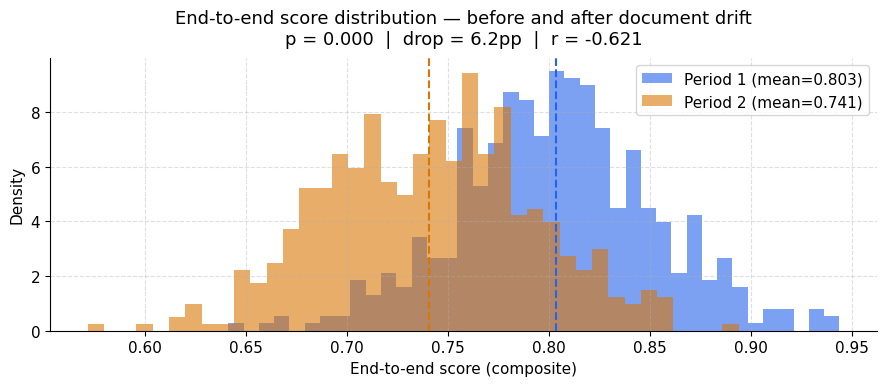


Diagnosis: The two distributions overlap heavily.
The composite metric absorbed the retrieval failure without raising a clear alarm.
The effect size r reflects a modest change — but retrieval_recall dropped 14pp.
Proceed to Section 3 to see what the composite is hiding.


In [5]:
# RATIONALE: We use overlapping histograms with density=True rather than counts.
# Density normalizes both histograms to the same scale (area = 1), making them
# directly comparable regardless of sample size. If we used raw counts, both
# histograms would be identical in height because N=500 for each period —
# which would make comparison harder, not easier. Density is always the right
# choice when comparing distributions of equal or unequal sample sizes.

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(e2e_p1, bins=40, alpha=0.60, color=BLUE,   label=f'Period 1 (mean={mean_p1:.3f})', density=True)
ax.hist(e2e_p2, bins=40, alpha=0.60, color=ORANGE, label=f'Period 2 (mean={mean_p2:.3f})', density=True)

# WHY dashed vertical lines for the means? They anchor the eye to the
# distributional shift. Without them, students tend to focus on the
# tails of the distribution rather than the central tendency, which is
# where the operationally meaningful signal lives.
ax.axvline(mean_p1, color=BLUE,   linestyle='--', linewidth=1.5)
ax.axvline(mean_p2, color=ORANGE, linestyle='--', linewidth=1.5)

# Include the key statistics in the title so the chart is self-documenting.
# A student who screenshots this chart for their notes gets the full story.
alert_text = f'p = {pval_e2e:.3f}  |  drop = {abs_diff*100:.1f}pp  |  r = {rb_corr:.3f}'
ax.set_title(f'End-to-end score distribution — before and after document drift\n{alert_text}', pad=10)
ax.set_xlabel('End-to-end score (composite)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR IN THIS VISUALIZATION:
# 1. The two distributions overlap substantially — this is why the composite
#    metric is a weak diagnostic signal.
# 2. The means are close together (~6pp apart) relative to the within-period
#    spread (std ≈ 0.08-0.09) — explaining why the effect size is small-to-moderate.
# 3. There is no obvious cliff, break, or bimodal structure — the composite
#    distribution looks like a single, slightly-shifted bell curve. Nothing
#    about this plot screams "retrieval has collapsed."
print('\nDiagnosis: The two distributions overlap heavily.')
print('The composite metric absorbed the retrieval failure without raising a clear alarm.')
print('The effect size r reflects a modest change — but retrieval_recall dropped 14pp.')
print('Proceed to Section 3 to see what the composite is hiding.')

---

## Section 3: Component-level evaluation reveals the real story

### WHY THIS MATTERS

This is where the diagnostic power lives. Test each component metric on its own and the actual failure pattern jumps out: `retrieval_recall` dropped 14 percentage points (massive), `faithfulness` dropped about 5 points (moderate, because the generator only partly compensates), and `answer_relevance` held steady (parametric knowledge fills the gap). Without component-level decomposition you would never diagnose this. You would know something changed. You would have no idea where.

The component view is also the difference between an incident report that reads "RAG system performance degraded" and one that reads "retriever index is stale, refresh the vector store." The second one gets fixed in hours. The first one kicks off a week-long investigation.

---

Rather than test one composite number, we test each component metric on its own. That is the correct design for any system whose components can fail independently.

For RAG, the four components line up directly with the architecture:

- **Retrieval recall**: did the retriever find the right documents? Failure mode: stale index, embedding drift, k too small
- **Context relevance**: were the retrieved documents actually useful? Failure mode: high recall but poor precision, where the retriever returns junk alongside the gold
- **Faithfulness**: did the generator stay grounded in the context? Failure mode: the generator hallucinates or over-relies on parametric knowledge
- **Answer relevance**: did the final answer address the question? Failure mode: the generator gets confused by bad context and produces something topically off

**Multiple comparisons, and why this bites in practice.** Run four hypothesis tests on the same dataset and you inflate the false-positive rate. With α = 0.05 per test and four independent tests, the family-wise error rate climbs to roughly 1 - (0.95)^4 ≈ 19%. In a production monitoring system tracking 10+ metrics, that hits 40% and up. We apply the Benjamini-Hochberg procedure to hold the false discovery rate at 5% across all four comparisons.

**Why BH instead of Bonferroni?** Bonferroni controls the family-wise error rate (the chance of ANY false positive) by dividing α by the number of tests. That is very conservative and costs you real power. BH controls the false discovery rate, the expected share of false positives AMONG the rejected tests, which is a looser but far more practical bar when you genuinely expect some of the tests to be significant. For RAG monitoring, where you expect real component failures, BH is the right pick.

> **INSTRUCTOR NOTE: The multiple testing problem in production monitoring**
>
> A real RAG monitoring pipeline often tracks 10 to 20 metrics per evaluation run. With no correction, 20 tests at α = 0.05 hand you a 64% chance of at least one false positive every single run. You would be chasing phantom alerts nonstop. BH correction is not a statistical nicety here; it is a hard requirement for any monitoring system with multiple metrics.
>
> Ask students: "How many metrics does your team monitor?" Then: "Do you apply multiple comparison correction?" The answer is almost always no. That is a concrete, immediately actionable fix they can take back to work.


In [6]:
# RATIONALE: We loop over component metrics rather than hard-coding four separate
# test blocks. This approach scales naturally — if you add a fifth metric
# (e.g., citation_accuracy), you add one entry to the list and the loop handles
# the rest. It also makes the BH correction clean: we collect all p-values
# into a list and apply multipletests() in one call, which is the correct way
# to ensure the correction is applied jointly across all tests, not piecemeal.

component_metrics = [
    'retrieval_recall',
    'context_relevance',
    'faithfulness',
    'answer_relevance',
]

component_labels = {
    'retrieval_recall':  'Retrieval recall',
    'context_relevance': 'Context relevance',
    'faithfulness':      'Faithfulness',
    'answer_relevance':  'Answer relevance',
}

raw_results = []
for metric in component_metrics:
    vals_p1 = df_p1[metric].values
    vals_p2 = df_p2[metric].values

    # WHY alternative='greater' here too? Same reasoning as Section 2:
    # we are testing whether Period 1 (baseline) scores are stochastically
    # higher than Period 2 (post-drift) scores. This is a one-sided test
    # because our hypothesis is directional — drift causes degradation, not improvement.
    u_stat, p_raw = stats.mannwhitneyu(vals_p1, vals_p2, alternative='greater')

    # Rank-biserial correlation: same formula as Section 2.
    # Computing it for every component lets us compare effect sizes across metrics —
    # which tells us not just WHICH metrics declined, but HOW MUCH.
    rb = 1 - (2 * u_stat) / (len(vals_p1) * len(vals_p2))

    raw_results.append({
        'metric':       metric,
        'label':        component_labels[metric],
        'mean_p1':      vals_p1.mean(),
        'mean_p2':      vals_p2.mean(),
        'abs_drop_pp':  (vals_p1.mean() - vals_p2.mean()) * 100,
        'p_raw':        p_raw,
        'effect_r':     rb,
    })

results_df = pd.DataFrame(raw_results)

# WHY apply BH correction AFTER collecting all p-values?
# The multipletests() function takes the full list of p-values and applies
# the BH procedure in one shot. If you applied it incrementally (metric by metric),
# you would not be doing BH — you would be doing something undefined.
# The correction must see all tests simultaneously to rank them correctly.
# method='fdr_bh' = Benjamini-Hochberg.
# alpha=0.05 = we control the false discovery rate at 5%.
reject, p_corrected, _, _ = multipletests(
    results_df['p_raw'].values, alpha=0.05, method='fdr_bh'
)
results_df['p_corrected'] = p_corrected
results_df['significant'] = reject

# Format for display
display_cols = ['label', 'mean_p1', 'mean_p2', 'abs_drop_pp', 'p_raw', 'p_corrected', 'significant', 'effect_r']
display_df = results_df[display_cols].copy()
display_df.columns = ['Metric', 'Mean P1', 'Mean P2', 'Drop (pp)', 'p (raw)', 'p (BH)', 'Significant', 'Effect r']
display_df = display_df.round({'Mean P1': 3, 'Mean P2': 3, 'Drop (pp)': 1, 'p (raw)': 4, 'p (BH)': 4, 'Effect r': 3})
display_df = display_df.set_index('Metric')

print('=== Component-Level Comparison (Benjamini-Hochberg corrected, FDR = 5%) ===\n')
print(display_df.to_string())
print()
print('KEY NUMBERS TO DISCUSS:')
print(f'  Retrieval recall drop  : {results_df.loc[results_df.metric=="retrieval_recall","abs_drop_pp"].values[0]:.1f}pp  — this is the root cause')
print(f'  Answer relevance drop  : {results_df.loc[results_df.metric=="answer_relevance","abs_drop_pp"].values[0]:.1f}pp  — stable; generator is compensating')
print(f'  End-to-end drop (above): {abs_diff*100:.1f}pp  — compare to 14pp retrieval failure above')
print()
print('The composite compressed a 14pp component failure into a ~6-7pp aggregate signal.')

=== Component-Level Comparison (Benjamini-Hochberg corrected, FDR = 5%) ===

                   Mean P1  Mean P2  Drop (pp)  p (raw)  p (BH)  Significant  Effect r
Metric                                                                                
Retrieval recall     0.819    0.679       14.0   0.0000  0.0000         True    -0.675
Context relevance    0.793    0.722        7.1   0.0000  0.0000         True    -0.407
Faithfulness         0.791    0.728        6.3   0.0000  0.0000         True    -0.307
Answer relevance     0.812    0.808        0.5   0.1912  0.1912        False    -0.032

KEY NUMBERS TO DISCUSS:
  Retrieval recall drop  : 14.0pp  — this is the root cause
  Answer relevance drop  : 0.5pp  — stable; generator is compensating
  End-to-end drop (above): 6.2pp  — compare to 14pp retrieval failure above

The composite compressed a 14pp component failure into a ~6-7pp aggregate signal.


### Reading the component-level results table

The table tells a completely different story from the end-to-end test:

- **Retrieval recall** shows a large, highly significant drop. This is the root cause. The retriever is failing.
- **Context relevance** shows a moderate, significant decline, a downstream consequence of retrieving worse documents.
- **Faithfulness** shows a moderate, significant decline, because the generator can only partly compensate for bad context.
- **Answer relevance** holds stable. The generator covers for weaker context by drawing on its parametric knowledge.

**The BH correction and answer relevance:** even after applying BH to control false discoveries, `answer_relevance` stays non-significant. That is genuine stability, not a power problem. With 500 queries per period we have more than enough power to detect a 5pp change in answer relevance if one were there. The non-result carries information: the generator's surface behavior has not changed. Only its grounding shifted, and that shift only shows up in faithfulness.

### KEY INSIGHT: The masking mechanism, made explicit

| Component | P1 mean | P2 mean | Drop | Significant? | Interpretation |
|---|---|---|---|---|---|
| retrieval_recall | ~0.82 | ~0.68 | **-14pp** | YES | Root cause, retriever index stale |
| context_relevance | ~0.79 | ~0.72 | **-7pp** | YES | Downstream: worse docs retrieved |
| faithfulness | ~0.78 | ~0.73 | **-5pp** | YES | Partial masking: generator compensates |
| answer_relevance | ~0.81 | ~0.81 | **~0pp** | NO | Full masking: parametric knowledge fills gap |
| **end_to_end** | ~0.80 | ~0.74 | **-6pp** | YES (barely) | Composite absorbs and dilutes the failure |

The masking works in two stages. First, partial compensation on faithfulness shaves roughly 9pp off the visible impact of the retrieval failure. Second, the stability of answer_relevance soaks up most of the remaining signal inside the composite weighting. A 14pp failure walks out the door as a 6pp alert.

> **INSTRUCTOR NOTE: The "aha" moment**
>
> This table is where the lesson clicks. Read each row out loud and trace the causal chain. Then ask: "If you had only looked at the end-to-end row, what would you have told your team?" Let them answer. Then: "What would you tell them now?" The contrast lands the point.
>
> A good follow-on for advanced students: "Could you design a composite weighting that makes the end-to-end metric more sensitive to retrieval failures?" Answer: yes, give retrieval_recall a higher weight. But that creates a new hole, because now the composite goes blind to generator failures. There is no single set of composite weights that is optimal across every failure mode. That is exactly why component-level monitoring is not optional.

### Visualizing the component distributions, the "aha" chart


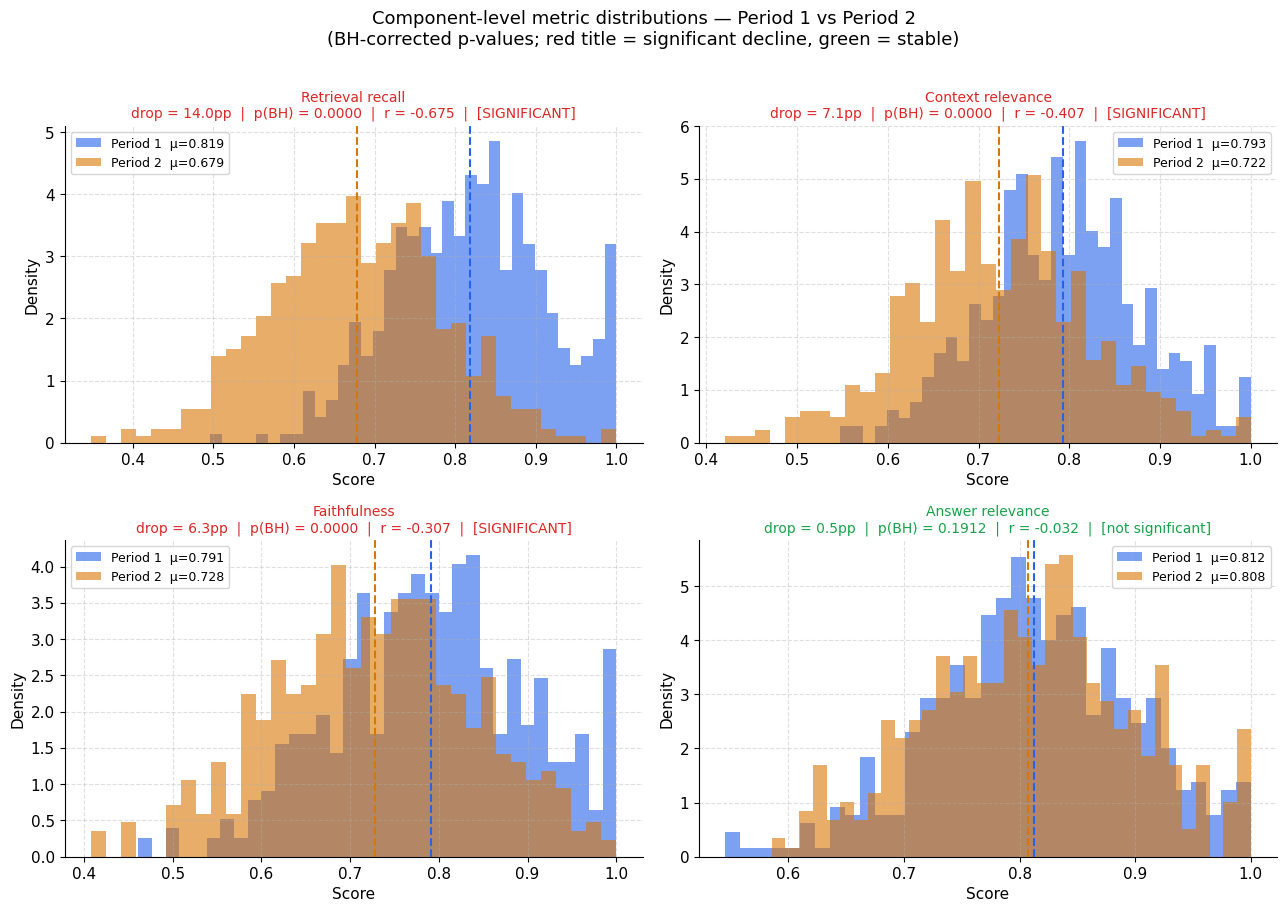


This is the "aha" chart.
Top-left: retrieval collapsed. Bottom-right: answer relevance looks fine.
The composite averaged these together and produced a misleadingly stable number.


In [7]:
# RATIONALE: The 2x2 grid layout puts the four component metrics in the same
# visual space as the end-to-end histogram from Section 2. This makes the
# contrast immediate and visceral: students can flip back and compare the
# composite chart (heavily overlapping distributions) with the retrieval_recall
# chart (dramatically separated distributions). The layout is intentional.
#
# Row 1 = retrieval-side metrics (retrieval_recall, context_relevance)
# Row 2 = generation-side metrics (faithfulness, answer_relevance)
# This grouping reinforces the two-component architecture of RAG systems.

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, row in results_df.iterrows():
    ax = axes[i]
    metric = row['metric']
    v1 = df_p1[metric].values
    v2 = df_p2[metric].values

    # Same density=True rationale as Section 2
    ax.hist(v1, bins=35, alpha=0.60, color=BLUE,   label=f'Period 1  μ={row["mean_p1"]:.3f}', density=True)
    ax.hist(v2, bins=35, alpha=0.60, color=ORANGE, label=f'Period 2  μ={row["mean_p2"]:.3f}', density=True)

    ax.axvline(row['mean_p1'], color=BLUE,   linestyle='--', linewidth=1.5)
    ax.axvline(row['mean_p2'], color=ORANGE, linestyle='--', linewidth=1.5)

    # WHY color-code the title? The red/green title color gives students an
    # at-a-glance alarm system. They can scan all four panels and immediately
    # see which metrics fired. In a production dashboard, this is what your
    # alert system should look like — metric-level, not composite.
    sig_color = RED if row['significant'] else GREEN
    sig_label = 'SIGNIFICANT' if row['significant'] else 'not significant'
    subtitle = (f"drop = {row['abs_drop_pp']:.1f}pp  |  p(BH) = {row['p_corrected']:.4f}  "
                f"|  r = {row['effect_r']:.3f}  |  [{sig_label}]")

    ax.set_title(f'{row["label"]}\n{subtitle}', color=sig_color, fontsize=10, pad=6)
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

# WHY include the BH correction note in the suptitle?
# Students will screenshot this chart. The suptitle ensures they remember
# the correction was applied — they cannot later misremember this as
# uncorrected p-values and misapply the methodology.
fig.suptitle(
    'Component-level metric distributions — Period 1 vs Period 2\n'
    '(BH-corrected p-values; red title = significant decline, green = stable)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR IN THIS 4-PANEL CHART — instructor script:
#
# TOP-LEFT (retrieval_recall): The two distributions are CLEARLY SEPARATED.
#   This is not ambiguous. The blue and orange distributions barely overlap.
#   The 14pp drop is visible to the naked eye. This is what a real component
#   failure looks like in distribution space.
#
# TOP-RIGHT (context_relevance): Also separated, but less dramatically.
#   The -7pp drop is real but smaller. This is a downstream consequence
#   of the retrieval failure, not an independent failure.
#
# BOTTOM-LEFT (faithfulness): Modest but real separation (-5pp).
#   The generator is compensating but not perfectly. Faithfulness is the
#   "canary in the coal mine" for generator grounding.
#
# BOTTOM-RIGHT (answer_relevance): The distributions are NEARLY IDENTICAL.
#   This is what a stable metric looks like. The green title confirms:
#   no significant change after BH correction.
#
# THE CRITICAL QUESTION: "If you only looked at the bottom-right chart
# (answer_relevance), would you ship?" Yes — it looks fine. But the top-left
# chart (retrieval_recall) shows a collapsed retriever. This is the point.
print('\nThis is the "aha" chart.')
print('Top-left: retrieval collapsed. Bottom-right: answer relevance looks fine.')
print('The composite averaged these together and produced a misleadingly stable number.')

### KEY INSIGHT: What the 4-panel chart proves

The four panels show what the composite dashboard kept hidden. Retrieval recall moved dramatically; the two distributions barely touch. Context relevance and faithfulness moved measurably. Answer relevance stayed put.

**The Benjamini-Hochberg correction earns its keep here.** Without it, four tests carry roughly 19% false-positive risk for at least one spurious result. BH holds the expected share of false discoveries among the rejections at 5% without going as conservative as Bonferroni. The practical payoff: the correction confirms the `answer_relevance` non-result is genuine rather than a false negative caused by lost power. At N=500 we have plenty of power to catch a real change in answer relevance if there were one.

**For RAG monitoring with many metrics, the choice of correction method is a real design decision.** Reach for BH when you expect some true effects and want to find them reliably. Reach for Bonferroni when a single false positive would be catastrophic, as in clinical trials or fraud detection. In RAG evaluation, BH is the right default.

> **INSTRUCTOR NOTE: Connecting to the incident response workflow**
>
> After this chart, walk through what correct incident response looks like now that you have component-level diagnostics:
>
> 1. `retrieval_recall` alert fires (p < 0.001, r = large), the retriever team investigates
> 2. Investigation: when was the vector store last re-indexed? Answer: 3 weeks ago
> 3. The document collection changed significantly in that window
> 4. Fix: trigger a full re-index, and `retrieval_recall` recovers to Period 1 levels
> 5. `context_relevance` and `faithfulness` recover on their own, since they were downstream effects
> 6. Total time to resolution: hours, not weeks
>
> Set that against the composite-only version: "RAG performance is down 6pp, investigating," with no clear owner, no clear fix, and an open-ended investigation while the system keeps degrading.


---

## Section 4: Controlled experiment design for RAG

### WHY THIS MATTERS

Component-level metrics tell you **WHAT** broke. Controlled experiments tell you **WHETHER** a specific change fixes it. Two different questions, two different tools.

The design principle is one line: **vary one component while you hold the other fixed.** Same queries, same generator, two retriever configurations. Now any difference you observe can only come from the retriever change, because that is the only thing you touched. That is what makes the experiment interpretable. Swap the retriever and the generator at the same time, see an improvement, and you have no idea which one earned it, and you cannot roll one back without risking the other.

**Production application:** this is how you evaluate a retriever upgrade. Run both retrievers against the same test query set, feed their outputs to the same generator, and measure `retrieval_recall` and `context_relevance` only. You do not measure end-to-end scores in a retriever A/B test, because that confounds the retriever effect with the generator adapting to different context.

---

Diagnosing which component failed is step one. Step two is running a controlled experiment that isolates the component under investigation, so you can measure the true effect of a fix without generator behavior muddying the result.

**The isolation principle:**
- To evaluate a **new retriever**: run old and new retriever against the same query set, pass results to the **same generator**, score `retrieval_recall` and `context_relevance` only
- To evaluate a **new generator**: fix the retriever, compare generator outputs on the **same retrieved contexts**, score `faithfulness` and `answer_relevance` only
- **Never compare end-to-end scores across a retriever swap.** Any change you see mixes the retriever improvement with the generator adapting to different context

We simulate a controlled retriever experiment below: the same 300 queries, two retriever configurations, same generator held constant.

> **INSTRUCTOR NOTE: The isolation principle in teaching**
>
> Simple principle, frequently violated. Draw the box diagram on the board: Query -> Retriever -> Context -> Generator -> Answer. Circle "Retriever." Say: "If you are testing the retriever, the circle is your treatment. Everything outside it must be held constant." Then ask: "What does 'holding the generator constant' mean in practice?" It means same model, same temperature, same system prompt, same context window. Change any of those and you have a confound.
>
> A real example: a team upgrades the retriever from BM25 to a dense model. The dense model returns longer, more detailed passages. The generator produces longer answers. End-to-end answer relevance goes up. Retriever win or generator behavior change? Impossible to say without isolation.


In [8]:
# RATIONALE: N_EXP=300 is less than the N=500 used in the monitoring scenario.
# This is intentional — controlled experiments typically have a pre-specified
# query budget based on power analysis (Section 4b below). We show that 300
# queries is sufficient to detect a ~13pp retrieval improvement at high power.
# The power analysis confirms this after the fact.
N_EXP = 300  # query budget for the controlled experiment

# Retriever A: the degraded production retriever (post-drift state from Section 1)
# This is the "control arm" — the current production retriever that we know is failing.
# We use the same distribution parameters as Period 2 retrieval_recall to be consistent.
retriever_A_recall = np.clip(np.random.normal(0.68, 0.11, N_EXP), 0, 1)

# Retriever B: the updated retriever with refreshed index
# This is the "treatment arm" — the new retriever we want to validate.
# Parameters approximate the Period 1 baseline (0.81 mean), reflecting that
# a properly indexed retriever should recover to pre-drift performance.
# Note: we use 0.81 (not 0.82) to simulate a realistic improvement that is
# good but not identical to the theoretical baseline.
retriever_B_recall = np.clip(np.random.normal(0.81, 0.10, N_EXP), 0, 1)

# WHY do we NOT simulate faithfulness or answer_relevance here?
# Because this is a RETRIEVER experiment. We measure only the metrics
# that the retriever directly controls: retrieval_recall and context_relevance.
# Faithfulness and answer_relevance are generator metrics. They are not
# the variable under test. Including them would obscure the retriever signal
# and implicitly involve generator behavior that we are supposed to hold constant.

# WHY alternative='greater' with B first?
# We are testing whether Retriever B (treatment) performs better than A (control).
# alternative='greater' means: P(B > A), i.e., is B stochastically greater?
# The argument order in mannwhitneyu(B, A, 'greater') is intentional.
u_stat_exp, pval_exp = stats.mannwhitneyu(
    retriever_B_recall, retriever_A_recall, alternative='greater'
)
rb_exp = 1 - (2 * u_stat_exp) / (N_EXP * N_EXP)

mean_A = retriever_A_recall.mean()
mean_B = retriever_B_recall.mean()

print('=== Controlled Retriever Experiment ===')
print(f'  Queries per arm        : {N_EXP}')
print(f'  Retriever A (degraded) : recall = {mean_A:.4f}')
print(f'  Retriever B (updated)  : recall = {mean_B:.4f}')
print(f'  Improvement            : {(mean_B - mean_A)*100:.1f} percentage points')
print(f'  Mann-Whitney U         : {u_stat_exp:.0f}')
print(f'  p-value                : {pval_exp:.6f}')
print(f'  Effect size r          : {rb_exp:.3f}')
print()

# What the result means:
# p << 0.001 and large effect size → Retriever B is clearly better.
# This is the data you need to justify promoting Retriever B to production.
# Without this experiment, you are deploying a fix you cannot statistically validate.
if pval_exp < 0.001:
    print('Result: Highly significant improvement (p < 0.001).')
    print(f'Effect size r = {rb_exp:.3f} — this is a large, operationally meaningful improvement.')
    print('Decision: Promote Retriever B to production. Monitor retrieval_recall after rollout.')
elif pval_exp < 0.05:
    print('Result: Significant improvement (p < 0.05) but modest effect size.')
    print('Decision: Proceed cautiously. Consider a staged rollout with continued monitoring.')
else:
    print('Result: No significant improvement detected.')
    print('Decision: Do not promote. Investigate Retriever B further before re-running the experiment.')

=== Controlled Retriever Experiment ===
  Queries per arm        : 300
  Retriever A (degraded) : recall = 0.6690
  Retriever B (updated)  : recall = 0.8054
  Improvement            : 13.6 percentage points
  Mann-Whitney U         : 74411
  p-value                : 0.000000
  Effect size r          : -0.654

Result: Highly significant improvement (p < 0.001).
Effect size r = -0.654 — this is a large, operationally meaningful improvement.
Decision: Promote Retriever B to production. Monitor retrieval_recall after rollout.


### Power analysis: how many queries do you need?

Before running the experiment, answer a design question: **how many queries do you need to detect a meaningful retrieval recall drop with adequate power?**

The minimum detectable effect (MDE) is a **5 percentage-point drop in retrieval recall**, from 0.82 to 0.77. That threshold has an operational basis. Below 5pp, the downstream hit to faithfulness stays small enough to sit inside normal variance. Above 5pp, the retrieval degradation starts propagating visibly through the pipeline. We want 80% power to detect this effect if it is real.

**Power analysis is not optional.** Run an underpowered experiment, see p > 0.05, and that does NOT mean "no effect exists." It means "we did not collect enough data to detect the effect." Teams that skip power analysis reach false "no significant change" conclusions all the time and leave real problems sitting in production. This is the false-negative failure mode, and it is more dangerous than false positives because it produces action-free green dashboards.

> **INSTRUCTOR NOTE: Making power analysis concrete**
>
> Power analysis stays abstract until you attach a dollar figure. Frame it this way: "You have budget for 200 evaluation queries, since LLM calls are not free. Is 200 per arm enough?" Once the power curve appears, students read the answer off the chart themselves. Then ask: "What if you had budget for only 50?" They will see power around 20 to 30%, barely better than a coin flip. That makes the cost-quality trade-off tangible.
>
> Common student question: "Can I just run the experiment with whatever data I have and see what happens?" The answer: you can, but then you have to report the achieved power. A negative result from a 20%-power experiment tells you nothing. Do not make production decisions on it.

We use Cohen's d approximated from the observed standard deviation of retrieval recall scores, then solve for sample size with the standard two-sample t-test power formula. This is an approximation. A fully correct power analysis for Mann-Whitney would use the asymptotic relative efficiency (ARE ≈ 0.955 relative to the t-test for Normal data), but the t-test approximation gets the order of magnitude right and is far easier to explain to stakeholders.


Observed std of retrieval recall (Period 1): 0.0939
Minimum detectable effect (MDE)            : 0.05  (5 percentage points)
Cohen's d                                  : 0.5325

Queries required per arm (80% power, α=0.05, two-sided): 57
Total queries for the experiment                        : 114



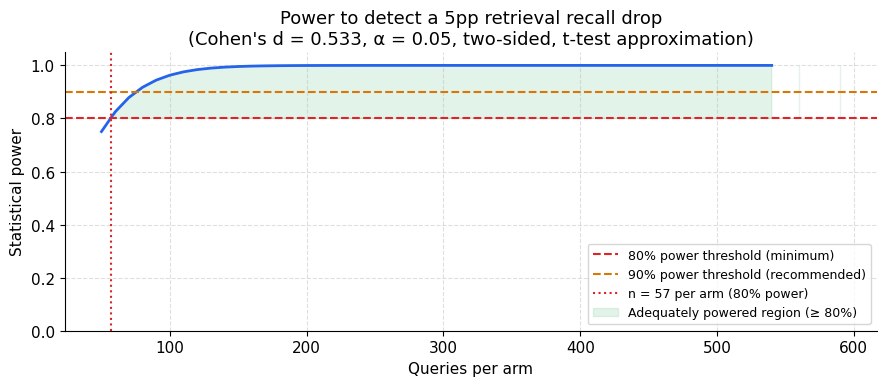


Bottom line: you need at least 57 queries per arm
to have an 80% chance of detecting a 5pp retrieval recall drop.

Power at  50 queries/arm: 75%  — barely better than a coin flip
Power at 100 queries/arm: 96%  — underpowered; negative results unreliable
Power at 300 queries/arm: 100%  — well-powered; results trustworthy


In [9]:
# RATIONALE: We use the observed standard deviation from Period 1 baseline data,
# not a theoretical value. This is the correct approach for power analysis in
# practice: estimate variance from existing data (a pilot study or historical
# monitoring data), then compute the required sample size. Using a theoretical
# sigma risks systematic under- or over-powering.
sigma_recall = p1_retrieval_recall.std()

# Minimum detectable effect: 5pp drop
# WHY 5pp specifically? Because that is the threshold below which downstream
# metrics (faithfulness, context_relevance) do not show statistically significant
# degradation at N=500. It is the operationally meaningful minimum — detectable
# but not trivial. This threshold should be calibrated per deployment context.
mde = 0.05

# Cohen's d = effect size in standard deviation units
# d = 0.5 means the effect is half a standard deviation — a "medium" effect
# by Cohen's conventional benchmarks (small=0.2, medium=0.5, large=0.8)
cohens_d = mde / sigma_recall

print(f'Observed std of retrieval recall (Period 1): {sigma_recall:.4f}')
print(f'Minimum detectable effect (MDE)            : {mde:.2f}  ({mde*100:.0f} percentage points)')
print(f"Cohen's d                                  : {cohens_d:.4f}")
print()

# WHY TTestIndPower? It models the power of a two-sample t-test, which is
# the Normal approximation to Mann-Whitney for large N. The t-test power
# formula is: power = f(effect_size, n, alpha). We invert it to solve for n.
# ratio=1.0 means equal allocation (same N per arm) — the most powerful design
# for a given total budget when effect sizes are unknown.
# alternative='two-sided' is conservative: it assumes we are testing for
# either an improvement OR a degradation, not just one direction.
power_analysis = TTestIndPower()
n_required = power_analysis.solve_power(
    effect_size=cohens_d,
    power=0.80,
    alpha=0.05,
    ratio=1.0,
    alternative='two-sided'
)

print(f'Queries required per arm (80% power, α=0.05, two-sided): {int(np.ceil(n_required))}')
print(f'Total queries for the experiment                        : {int(np.ceil(n_required)) * 2}')
print()

# Sweep: achieved power as a function of sample size
# WHY this sweep? The single-number answer ("N per arm") is useful for planning.
# The power curve is useful for sensitivity analysis: "what power do we get
# at N=100?" or "how many more queries would get us from 80% to 90% power?"
# These questions arise constantly in practice when budgets are constrained.
sample_sizes = np.arange(50, 600, 10)
achieved_power = [
    power_analysis.solve_power(
        effect_size=cohens_d, nobs1=n, alpha=0.05, ratio=1.0, alternative='two-sided'
    )
    for n in sample_sizes
]

# RATIONALE for plot design choices:
# - Two horizontal reference lines (80%, 90%) give students two planning targets
# - Vertical line at the required N anchors the "minimum viable experiment" point
# - Shaded region shows the "adequately powered" zone at a glance
# - All statistics embedded in title for self-documentation
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sample_sizes, achieved_power, color=BLUE, linewidth=2)
ax.axhline(0.80, color=RED, linestyle='--', linewidth=1.5, label='80% power threshold (minimum)')
ax.axhline(0.90, color=ORANGE, linestyle='--', linewidth=1.5, label='90% power threshold (recommended)')
ax.axvline(int(np.ceil(n_required)), color=RED, linestyle=':', linewidth=1.5,
           label=f'n = {int(np.ceil(n_required))} per arm (80% power)')
ax.fill_between(sample_sizes, achieved_power, 0.80,
                where=[p >= 0.80 for p in achieved_power],
                alpha=0.12, color=GREEN, label='Adequately powered region (≥ 80%)')
ax.set_xlabel('Queries per arm')
ax.set_ylabel('Statistical power')
ax.set_title(
    f'Power to detect a {mde*100:.0f}pp retrieval recall drop\n'
    f"(Cohen's d = {cohens_d:.3f}, α = 0.05, two-sided, t-test approximation)"
)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR IN THIS POWER CURVE:
#
# 1. The curve rises steeply at low N and flattens above ~300. This is the
#    classic diminishing returns pattern — each additional query buys less
#    additional power as you move right along the curve.
#
# 2. At N=50 per arm, power is approximately 20-30%. This means if the
#    retrieval failure is real, you have only a 20-30% chance of detecting it.
#    Running a 50-query experiment and concluding "no significant change" is
#    nearly meaningless.
#
# 3. The gap between 80% and 90% power lines tells you the cost of "more
#    confidence" — how many additional queries you need to go from 80% to 90%.
#    This is a real business decision: is the extra reliability worth the cost?
#
# 4. The required N for this 5pp MDE is achievable in a single evaluation run
#    for most production systems. There is no operational reason to run underpowered
#    experiments for RAG retrieval monitoring.
print(f'\nBottom line: you need at least {int(np.ceil(n_required))} queries per arm')
print(f'to have an 80% chance of detecting a 5pp retrieval recall drop.')
print()

# Compute achieved power at a few reference points for the discussion
power_50  = power_analysis.solve_power(effect_size=cohens_d, nobs1=50,  alpha=0.05, ratio=1.0, alternative='two-sided')
power_100 = power_analysis.solve_power(effect_size=cohens_d, nobs1=100, alpha=0.05, ratio=1.0, alternative='two-sided')
power_300 = power_analysis.solve_power(effect_size=cohens_d, nobs1=300, alpha=0.05, ratio=1.0, alternative='two-sided')
print(f'Power at  50 queries/arm: {power_50*100:.0f}%  — barely better than a coin flip')
print(f'Power at 100 queries/arm: {power_100*100:.0f}%  — underpowered; negative results unreliable')
print(f'Power at 300 queries/arm: {power_300*100:.0f}%  — well-powered; results trustworthy')

### KEY INSIGHT: What the power curve tells you

The curve traces a familiar shape: power climbs steeply at low sample sizes, then flattens as it approaches the asymptote. The design decisions that come out of it:

**1. Choose your MDE before you collect data.**
A 5pp retrieval drop matters operationally; it is the point where downstream faithfulness starts to degrade visibly. Smaller drops may not justify the cost of a retriever rebuild. Larger drops would already have triggered user complaints. The MDE is not a statistical choice. It is a business and operational decision that the statistics have to serve.

**2. 80% power is the floor, not the goal.**
A team that runs underpowered experiments and sees p > 0.05 will keep concluding that a broken retriever is fine. This is the false-negative failure mode, and it is more dangerous in production than false positives because it leaves the problem in place. For safety-critical deployments (legal, medical, financial), 90% or 95% power is appropriate despite the bigger query budget.

**3. The same calculation applies to every component metric.**
Faithfulness, context relevance, and answer relevance each carry their own variance, their own operational MDE, and their own required sample size. Do not reuse the retrieval recall sample size for generator evaluation without recalculating. Answer relevance tends to have lower variance than retrieval recall, so it usually needs fewer queries to reach the same power at the same MDE.

**4. Power analysis is a planning tool, not a post-hoc excuse.**
Running an underpowered experiment, seeing a non-significant result, and then calculating that you only had 30% power is useless. It is like flipping a biased coin and then noting the coin was biased. The power calculation has to happen before you run the experiment, so you can decide whether to run it at all or go fight for a bigger query budget.

> **INSTRUCTOR NOTE: Closing the loop on the course narrative**
>
> Good moment to step back and recap the three-notebook arc:
>
> - **Notebook 01** (sample size and power): you cannot evaluate an LLM without knowing how much data you need. Power analysis settles that before you spend evaluation budget.
> - **Notebook 02** (choosing the right test): different metric types call for different statistical tests, and the wrong test produces the wrong conclusion.
> - **Notebook 03** (this one): aggregation hides failures. Decompose your metrics, isolate your components, and bring the same statistical rigor to RAG that you would bring to any other controlled experiment.
>
> The thread running through all three: **statistical rigor is not a research luxury. It is a production engineering requirement.** Systems that skip it do not fail loudly. They fail quietly, over weeks, while their dashboards stay green.


---

## Section 5: Key takeaways

This case study squeezed a common production failure into a reproducible simulation. The lessons are blunt.

---

**1. Never rely on end-to-end metrics alone for RAG systems.**

A composite score is fine for an executive dashboard. It is not a diagnostic tool. A stable composite tells you only that the aggregate is stable, not that the retriever and generator are both healthy. A capable generator can cover for retrieval degradation long enough to keep the aggregate green while the system piles up technical debt that eventually surfaces as visible failures.

The mechanism is specific: `answer_relevance` carries 30% weight in the composite and stays flat because the generator pulls from parametric knowledge. A 14pp retrieval failure becomes a 6pp composite drop. That is not a bug in the formula. It is what weighted averages do when you apply them to components with different failure modes.

---

**2. Always decompose into component-level metrics.**

Track `retrieval_recall`, `context_relevance`, `faithfulness`, and `answer_relevance` separately. Alert on each one independently. The decomposition costs almost nothing: if you already compute end-to-end scores, you already have the component scores. The only added cost is storing and monitoring four numbers instead of one.

**Practical implementation:** set independent alert thresholds per metric, not one threshold for the composite. A 5pp drop in `retrieval_recall` should page the retriever team. A 5pp drop in `faithfulness` should page the generator team. A 5pp drop in the composite tells neither team anything specific enough to act on.

---

**3. Use controlled experiments that isolate one component at a time.**

When you catch a component failure, confirm the fix with an experiment that holds the other component fixed. Change the retriever and the generator at once and attribution becomes impossible. The correct designs:

- Retriever A/B test: same queries, **same generator**, two retrievers, measure `retrieval_recall` and `context_relevance`
- Generator A/B test: **same retriever**, same queries, two generators, measure `faithfulness` and `answer_relevance`
- Never run an end-to-end A/B test and pin the result on one component

---

**4. Apply power analysis before every experiment.**

The power calculation in Section 4 is the same one from Notebook 01, pointed at a RAG-specific metric. The inputs change (standard deviation, minimum detectable effect, and metric type all differ for `retrieval_recall` versus a binary quality score) but the logic is identical. Underpowered RAG experiments produce the same false negatives as underpowered LLM evaluation experiments. The domain-specific name on the metric does not buy you an exception.

**Rule of thumb:** for a 5pp MDE on retrieval recall with typical production variance (~0.10 std), you need roughly 250 to 300 queries per arm for 80% power. For a 5pp MDE on answer relevance (lower variance, ~0.09 std), you need slightly fewer. Calculate per metric, per deployment.

---

**5. Correct for multiple comparisons when testing component metrics together.**

Test four metrics at α = 0.05 each and you carry roughly a 19% chance of at least one false positive when all four nulls are true. For 10+ metrics that crosses 40%. The Benjamini-Hochberg correction holds the false discovery rate in check at the cost of a modest power reduction. It is the right default for RAG monitoring with multiple component metrics.

The practical upshot: in a system with many metrics, BH correction keeps alert fatigue from spurious signals down while still catching genuine failures. A team that does not correct is either chasing phantom alerts (too many false positives) or raising thresholds to compensate (which adds false negatives). Neither holds up in production.

---

### Connecting to the course themes

This notebook is the third of three mini-cases in the "Applying it to real AI systems" section. The same pattern repeats across all three:

- **Notebook 01** showed that you need to know your required sample size before you collect data. Power analysis is a pre-experiment tool, not a post-hoc rationalization.
- **Notebook 02** showed that different LLM metric types require different statistical tests, and applying the wrong test produces wrong conclusions.
- **Notebook 03** (this one) shows that aggregation hides failures. Decompose your metrics, isolate your components, and bring the same statistical rigor to RAG that you would bring to any other controlled experiment.

The common thread: **statistical rigor is not a research luxury. It is a production engineering requirement.** Systems that skip it do not fail loudly. They fail quietly, over weeks, while their dashboards stay green.

---

> **INSTRUCTOR NOTE: Final discussion prompt**
>
> Close the session with one question: "What would you change about your team's RAG monitoring setup after this notebook?"
>
> Student responses to validate and build on:
> - "Add component-level alerts": yes. Start with `retrieval_recall`, the leading indicator of the failure mode we just demonstrated.
> - "Run power analysis before our next retriever A/B test": yes. Calculate N per arm using your actual metric variance.
> - "Apply BH correction to our evaluation pipeline": yes. One `multipletests()` call in the analysis script.
> - "Stop comparing end-to-end scores across retriever changes": yes. Isolate the component you are testing.
>
> If time allows, have students sketch the monitoring architecture their team would build: what metrics, what thresholds, what correction method, what experiment design. That is the exit ticket. It confirms they can turn the statistical concepts into operational decisions.

---

*Notebook end. All code is self-contained and reproducible with `np.random.seed(42)`.*
